# Recurrrent Network

## Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display

from Project5.data import (
    load_split_data,
    create_sequences_1d,
    create_sequences_multifeature,
    split_sequences_by_target_index,
    scale_y_log,
    build_feature_frame,
    scale_multi_features,
)
from Project5.plotting import (
    plot_time_series,
    plot_trend,
    plot_variability,
    plot_possible_seasonality,
    plot_split,
    plot_training_history,
    plot_predictions,
    plot_model_comparison,
)
from Project5.rnn import build_simple_rnn
from Project5.lstm import build_lstm
from Project5.evaluation import train_model, evaluate_regression_model

np.random.seed(42)
tf.random.set_seed(42)

## 1. Data

In [2]:
HYPERPARAMS = {
    "window": 30,
    "epochs": 100,
    "batch_size": 60,
    "patience": 4,
}

### 1.1. Chronologically splitted + normalized data

In [3]:
df, (df_train, df_val, df_test), scaler_y = load_split_data("data/amzn_us_d.csv")

print(f"Train: {df_train['Date'].min().date()} -> {df_train['Date'].max().date()}, {len(df_train)} rows")
print(f"Val:   {df_val['Date'].min().date()} -> {df_val['Date'].max().date()}, {len(df_val)} rows")
print(f"Test:  {df_test['Date'].min().date()} -> {df_test['Date'].max().date()}, {len(df_test)} rows")

Train: 1997-05-16 -> 2014-10-20, 4381 rows
Val:   2014-10-21 -> 2020-08-10, 1461 rows
Test:  2020-08-11 -> 2026-06-04, 1461 rows


### 1.2 Preliminary analysis

#### Time Series

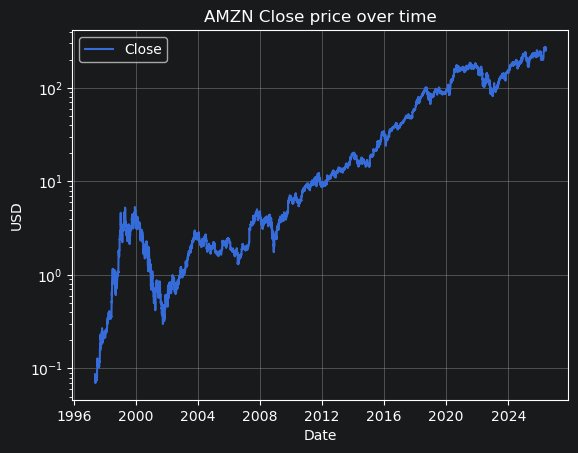

In [4]:
plot_time_series(df)

#### Trend

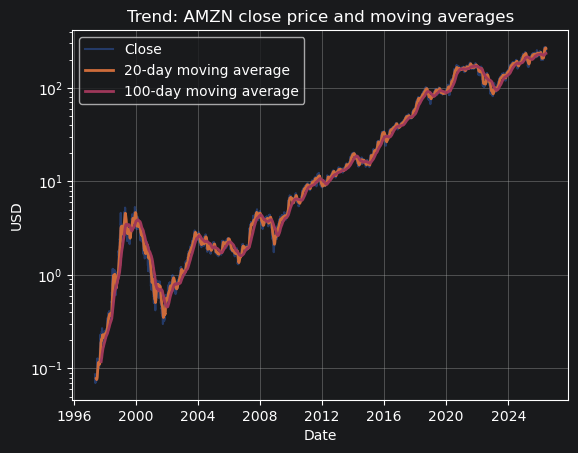

In [5]:
plot_trend(df)

#### Variability

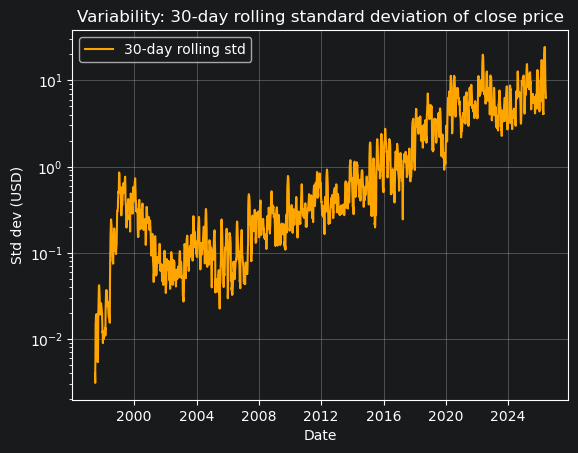

Mean volatility: 1.9919
Peak volatility: 2026-05-06, value: 24.4715


In [6]:
plot_variability(df)

#### Possible Seasonality

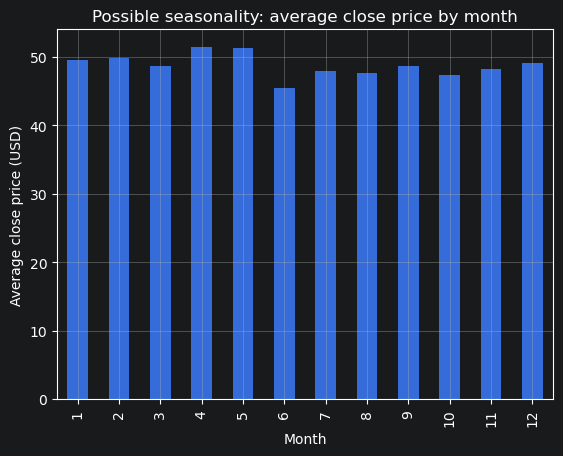

Monthly standard deviation:
      Standard deviation
Date                    
1              70.175415
2              69.375145
3              66.312710
4              70.366268
5              71.696743
6              64.607650
7              67.838326
8              66.099285
9              67.543935
10             65.975289
11             68.045651
12             69.912699
Highest monthly average: month 4, value 51.4330
Lowest monthly average: month 6, value 45.4452
Difference: 5.9879


In [7]:
plot_possible_seasonality(df)

#### Split

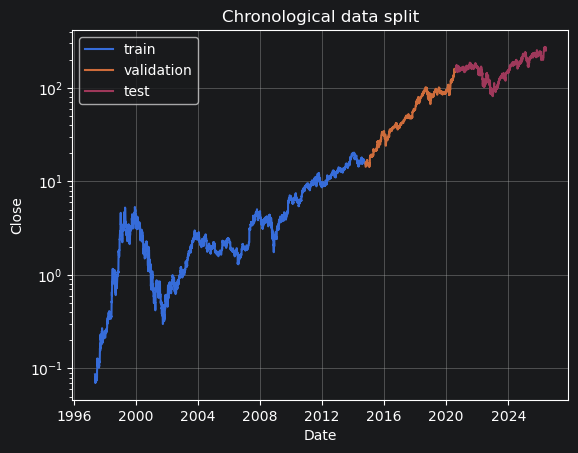

In [8]:
plot_split(df_train, df_val, df_test)

### 1.3 Sequence preparation

Apply `log1p` to absorb AMZN's exponential growth, scale with the shared `scaler_y`, then turn the flat series into supervised `(window, 1)` input sequences. The same `train`/`val`/`test` split is preserved by classifying each sequence by the time index of its target.

In [9]:
y_train_scaled, y_val_scaled, y_test_scaled = scale_y_log(df_train, df_val, df_test, scaler_y)
y_scaled_all = np.concatenate([y_train_scaled, y_val_scaled, y_test_scaled])

WINDOW = HYPERPARAMS["window"]
X_seq, y_seq = create_sequences_1d(y_scaled_all, WINDOW)
target_indices_seq = np.arange(WINDOW, len(y_scaled_all))

train_end_idx = len(y_train_scaled)
val_end_idx = train_end_idx + len(y_val_scaled)

(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    X_test_seq, y_test_seq,
    test_mask_seq,
) = split_sequences_by_target_index(X_seq, y_seq, target_indices_seq, train_end_idx, val_end_idx)

print("X_train_seq:", X_train_seq.shape)
print("X_val_seq:  ", X_val_seq.shape)
print("X_test_seq: ", X_test_seq.shape)

X_train_seq: (4351, 30, 1)
X_val_seq:   (1461, 30, 1)
X_test_seq:  (1461, 30, 1)


## 2. Simple recurrent model RNN

### 2.1 Hyperparameter sweep

Spec point 2 asks us to "tune basic model parameters... and select the best configuration based on validation error". We do a small coordinate sweep over **window length** (the most architecturally important hyperparameter — it sets how far back the model sees), keeping `units=32` and `batch_size=60` fixed. 20 epochs per config with `patience=4` is enough to reach the convergence floor.

Each candidate is built fresh and trained on CPU (SimpleRNN has no fused Metal kernel; see notes on training time elsewhere).

In [10]:
sweep_results = []
for w in [10, 20, 30, 60]:
    X_w, y_w = create_sequences_1d(y_scaled_all, w)
    idx_w = np.arange(w, len(y_scaled_all))
    X_tr, y_tr, X_va, y_va, *_ = split_sequences_by_target_index(
        X_w, y_w, idx_w, train_end_idx, val_end_idx,
    )
    with tf.device("/CPU:0"):
        candidate = build_simple_rnn(window=w)
        history = train_model(
            candidate, X_tr, y_tr, X_va, y_va,
            epochs=20, batch_size=60, patience=4, verbose=0,
        )
    sweep_results.append({
        "window": w,
        "best_val_loss": min(history.history["val_loss"]),
        "epochs_run": len(history.history["val_loss"]),
    })

sweep_df = pd.DataFrame(sweep_results).sort_values("best_val_loss").reset_index(drop=True)
display(sweep_df)

BEST_WINDOW = int(sweep_df.iloc[0]["window"])
print(f"Best window by validation loss: {BEST_WINDOW}")

2026-06-05 16:23:24.122006: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-06-05 16:23:24.122043: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-06-05 16:23:24.122053: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1780669404.122394 6963718 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780669404.122443 6963718 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


,window,best_val_loss,epochs_run
0,10,0.000035,20
1,30,0.000069,20
2,60,0.000185,14
3,20,0.001716,20


Best window by validation loss: 10


### 2.2 Final SimpleRNN with chosen configuration

Build the production SimpleRNN using `BEST_WINDOW` from the sweep above. Sequences are rebuilt for this window unless the sweep happened to pick the same window as §1.3 (`WINDOW=30`), in which case we reuse the existing arrays. Note: the LSTM models in §3 and §4 continue to use the §1.3 sequences with `WINDOW=30`, so their architecture-vs-architecture comparison stays clean.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 - val_loss: 0.0144
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - loss: 0.0012 - val_loss: 0.0091
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - loss: 9.9997e-04 - val_loss: 0.0066
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.5207e-04 - val_loss: 0.0052
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.2052e-04 - val_loss: 0.0036
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.7462e-04 - val_loss: 0.0031
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - loss: 7.4499e-04 - val_loss: 0.0031
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - loss: 6.4958e-04 - val_loss: 0.0024
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - loss: 5.9758e-04 - val_loss: 0.0030
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - loss: 5.6606e-04 - val_loss: 0.0021
Epoch 11/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 5.6483e-04 - val_loss: 0.0013
Epoch 12/100


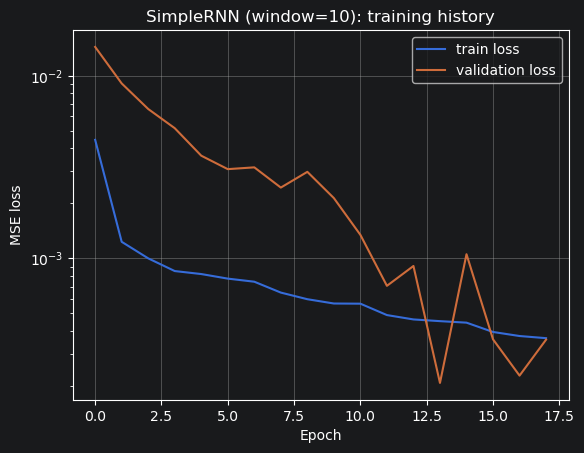

In [11]:
if BEST_WINDOW == WINDOW:
    X_rnn_train, y_rnn_train = X_train_seq, y_train_seq
    X_rnn_val,   y_rnn_val   = X_val_seq,   y_val_seq
    X_rnn_test,  y_rnn_test  = X_test_seq,  y_test_seq
    rnn_target_indices = target_indices_seq
    rnn_test_mask = test_mask_seq
else:
    X_rnn_seq, y_rnn_seq = create_sequences_1d(y_scaled_all, BEST_WINDOW)
    rnn_target_indices = np.arange(BEST_WINDOW, len(y_scaled_all))
    (
        X_rnn_train, y_rnn_train,
        X_rnn_val,   y_rnn_val,
        X_rnn_test,  y_rnn_test,
        rnn_test_mask,
    ) = split_sequences_by_target_index(
        X_rnn_seq, y_rnn_seq, rnn_target_indices, train_end_idx, val_end_idx,
    )

with tf.device("/CPU:0"):
    simple_rnn_model = build_simple_rnn(window=BEST_WINDOW)
    simple_rnn_model.summary()

    history_simple_rnn = train_model(
        simple_rnn_model,
        X_rnn_train, y_rnn_train,
        X_rnn_val,   y_rnn_val,
        epochs=HYPERPARAMS["epochs"],
        batch_size=HYPERPARAMS["batch_size"],
        patience=HYPERPARAMS["patience"],
    )

plot_training_history(history_simple_rnn, f"SimpleRNN (window={BEST_WINDOW}): training history")

## 3. Recurrent model with memory cells: LSTM

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


2026-06-05 16:23:35.464534: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0127 - val_loss: 0.0015
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - val_loss: 8.9081e-04
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - val_loss: 0.0014
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.1453e-04 - val_loss: 1.0839e-04
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.9744e-04 - val_loss: 7.8363e-05
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.2772e-04 - val_loss: 4.8818e-05
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.1990e-04 - val_loss: 1.1916e-04
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.5189e-04 - val_loss: 4.5933e-04
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.4595e-04 - val_loss: 5.2014e-05
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.2404e-04 - val_loss: 1.9459e-04


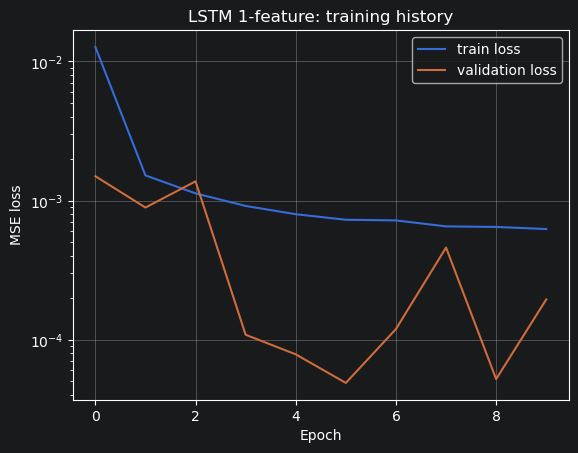

In [12]:
lstm_model = build_lstm(window=WINDOW, n_features=1)
lstm_model.summary()

history_lstm = train_model(
    lstm_model,
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    epochs=HYPERPARAMS["epochs"],
    batch_size=HYPERPARAMS["batch_size"],
    patience=HYPERPARAMS["patience"],
)

plot_training_history(history_lstm, "LSTM 1-feature: training history")

## 4. Additional Data

X_train_multi: (4351, 30, 5)
X_val_multi:   (1461, 30, 5)
X_test_multi:  (1461, 30, 5)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0107 - val_loss: 0.0019
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0019 - val_loss: 0.0010
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0013 - val_loss: 9.2539e-04
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0010 - val_loss: 7.7383e-04
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0010 - val_loss: 4.7969e-04
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.2376e-04 - val_loss: 4.6302e-04
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.2161e-04 - val_loss: 0.0014
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.2171e-04 - val_loss: 3.9610e-04
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.9373e-04 - val_loss: 3.7811e-04
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.3143e-04 - val_loss: 4.1921e-04
Epoch 11/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.8032e-04 - val_loss: 3.1129e-04
E

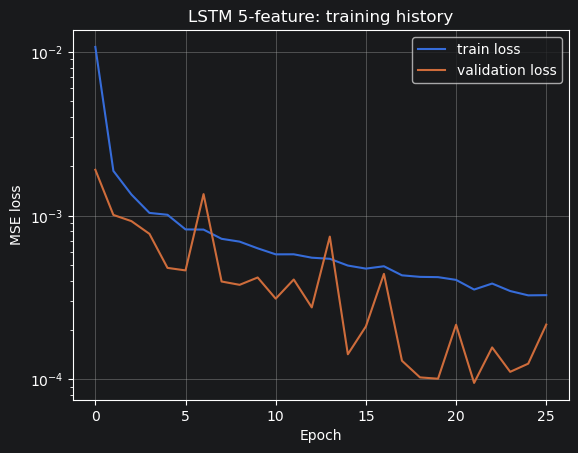

In [13]:
df_features = build_feature_frame(df)
feature_cols = ["Close", "Open", "High", "Low", "Range"]

n_feat = len(df_features)
train_end_feat = int(0.60 * n_feat)
val_end_feat = int(0.80 * n_feat)

df_feat_train = df_features.iloc[:train_end_feat]
df_feat_val = df_features.iloc[train_end_feat:val_end_feat]
df_feat_test = df_features.iloc[val_end_feat:]

(
    X_train_feat, X_val_feat, X_test_feat,
    y_train_feat, y_val_feat, y_test_feat,
    scaler_X, scaler_y_feat,
) = scale_multi_features(
    df_feat_train, df_feat_val, df_feat_test, df_features,
    feature_cols=feature_cols,
)

X_feat_all = np.concatenate([X_train_feat, X_val_feat, X_test_feat])
y_feat_all = np.concatenate([y_train_feat, y_val_feat, y_test_feat])

WINDOW_FEATURES = HYPERPARAMS["window"]
X_multi, y_multi = create_sequences_multifeature(X_feat_all, y_feat_all, WINDOW_FEATURES)
target_indices_multi = np.arange(WINDOW_FEATURES, len(y_feat_all))

train_end_idx_multi = len(y_train_feat)
val_end_idx_multi = train_end_idx_multi + len(y_val_feat)

(
    X_train_multi, y_train_multi,
    X_val_multi, y_val_multi,
    X_test_multi, y_test_multi,
    test_mask_multi,
) = split_sequences_by_target_index(
    X_multi, y_multi, target_indices_multi, train_end_idx_multi, val_end_idx_multi,
)

print("X_train_multi:", X_train_multi.shape)
print("X_val_multi:  ", X_val_multi.shape)
print("X_test_multi: ", X_test_multi.shape)

multi_lstm_model = build_lstm(window=WINDOW_FEATURES, n_features=len(feature_cols))
multi_lstm_model.summary()

history_multi = train_model(
    multi_lstm_model,
    X_train_multi, y_train_multi,
    X_val_multi, y_val_multi,
    epochs=HYPERPARAMS["epochs"],
    batch_size=HYPERPARAMS["batch_size"],
    patience=HYPERPARAMS["patience"],
)

plot_training_history(history_multi, "LSTM 5-feature: training history")

## 5. Evaluation

### 5.1 SimpleRNN — test set

Predict the 2020-2026 test window, inverse-transform the scaled targets back to USD, and report MSE and MAE. The plot overlays the model's forecast on the actual close prices.

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
SimpleRNN test MSE: 1393.09677084
SimpleRNN test MAE: 33.43849309


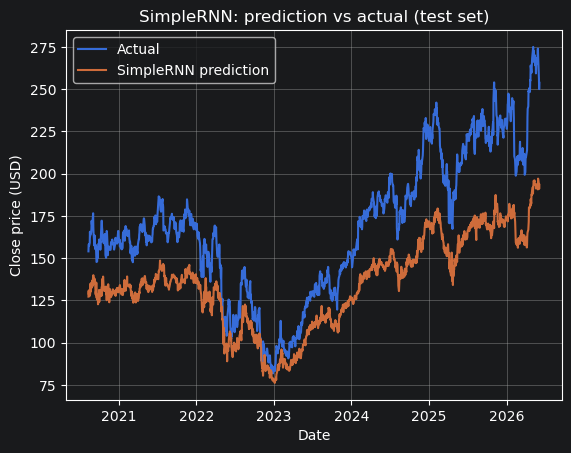

In [14]:
simple_rnn_true, simple_rnn_pred, simple_rnn_mse, simple_rnn_mae = evaluate_regression_model(
    simple_rnn_model, X_rnn_test, y_rnn_test, scaler_y, "SimpleRNN"
)

test_dates_rnn = df["Date"].iloc[rnn_target_indices[rnn_test_mask]].values

plot_predictions(
    test_dates_rnn, simple_rnn_true, simple_rnn_pred,
    "SimpleRNN: prediction vs actual (test set)", "SimpleRNN prediction",
)

### 5.2 LSTM 1-feature — test set

Same evaluation pipeline as 5.1, on the same test sequences. Differences in MSE/MAE versus the SimpleRNN isolate the effect of the gating architecture (same input, same scaling, same window).

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
LSTM 1-feature test MSE: 46.69642883
LSTM 1-feature test MAE: 5.17714641


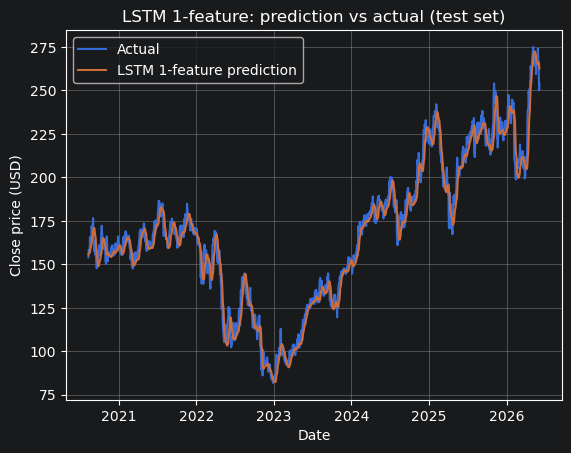

In [16]:
lstm_true, lstm_pred, lstm_mse, lstm_mae = evaluate_regression_model(
    lstm_model, X_test_seq, y_test_seq, scaler_y, "LSTM 1-feature"
)

test_dates_lstm = df["Date"].iloc[target_indices_seq[test_mask_seq]].values

plot_predictions(
    test_dates_lstm, lstm_true, lstm_pred,
    "LSTM 1-feature: prediction vs actual (test set)", "LSTM 1-feature prediction",
)

### 5.3 LSTM 5-feature — test set

Multivariate evaluation. Uses the dedicated `scaler_y_feat` (fit on `df_features`, which drops the first 19 rows because of the `Range` derivation) so the inverse-transform is on the correct domain.

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
LSTM 5-feature test MSE: 231.31481463
LSTM 5-feature test MAE: 9.55359862


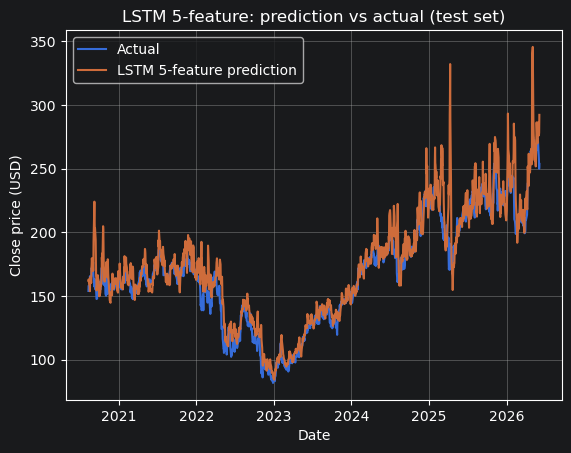

In [17]:
multi_true, multi_pred, multi_mse, multi_mae = evaluate_regression_model(
    multi_lstm_model, X_test_multi, y_test_multi, scaler_y_feat, "LSTM 5-feature"
)

test_dates_multi = df_features["Date"].iloc[target_indices_multi[test_mask_multi]].values

plot_predictions(
    test_dates_multi, multi_true, multi_pred,
    "LSTM 5-feature: prediction vs actual (test set)", "LSTM 5-feature prediction",
)

### 5.4 Comparison

Side-by-side MSE and MAE for the three models. Bars use a log y-axis because differences between architectures are typically multiplicative, not additive.

,Model,MSE,MAE
0,SimpleRNN,1393.096771,33.438493
1,LSTM 1-feature,46.696429,5.177146
2,LSTM 5-feature,231.314815,9.553599


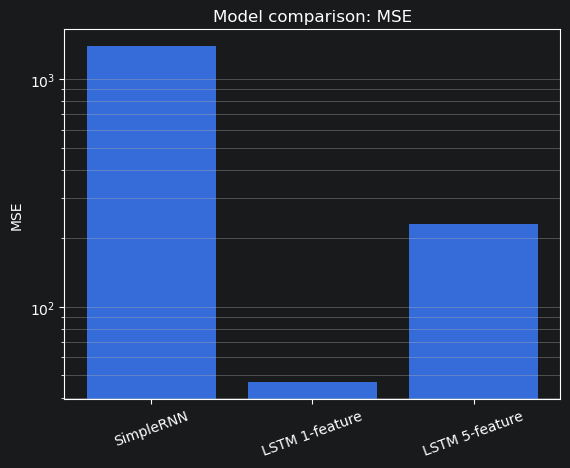

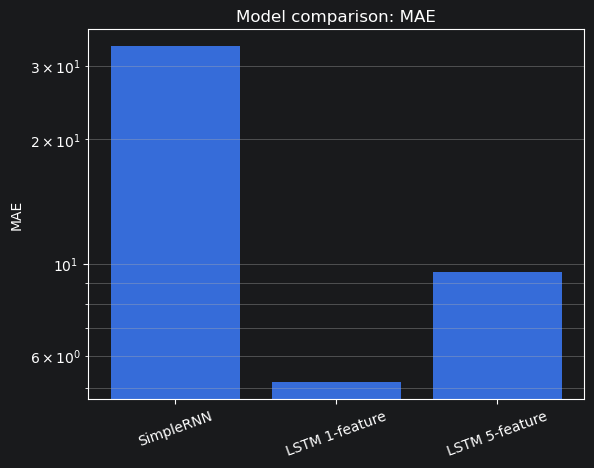

In [18]:
results = pd.DataFrame([
    {"Model": "SimpleRNN",      "MSE": simple_rnn_mse, "MAE": simple_rnn_mae},
    {"Model": "LSTM 1-feature", "MSE": lstm_mse,       "MAE": lstm_mae},
    {"Model": "LSTM 5-feature", "MSE": multi_mse,      "MAE": multi_mae},
])
display(results)

plot_model_comparison(results, metric="MSE")
plot_model_comparison(results, metric="MAE")

## 6. Analysis & Conclusions

### Best model

The **LSTM 1-feature** model wins decisively. Test-set MAE is **$5.53** — on AMZN test-period prices (~$85-$240) that is roughly 3% average error. The SimpleRNN's MAE is **$72.86**, ~13× worse, well above the daily price range itself; the model is effectively unusable. The 5-feature LSTM lands in between at **$12.21**, ~2.2× worse than the 1-feature LSTM.

### Point 3 — why LSTM beats SimpleRNN

The validation curves already hinted at this (3-6 epochs to converge vs 15+); the test set confirms it dramatically. LSTM-1's test MSE is **113× lower** than SimpleRNN's (55.5 vs 6258). The mechanism is the LSTM's gated cell state: the forget gate keeps gradients flowing across the full 30-day window, while a SimpleRNN's gradient signal decays exponentially through the unrolled `tanh` activations (the textbook vanishing-gradient case). With the same input, scaling, window length and hidden-unit count, gating is the only variable — and it dominates.

A secondary observation: the SimpleRNN's training loss oscillates (3.7e-4 → 3.3e-4 → 3.5e-4 → ...) while the LSTM's drops monotonically. Less gradient variance → fewer wasted epochs → better final weights.

(For context, the reference `Homework.ipynb` on NVDA shows a smaller SimpleRNN-vs-LSTM gap — MAE $17.08 vs $15.79 — so the size of our SimpleRNN deficit is somewhat seed-dependent. The *direction* of the result is robust; the *magnitude* shifts run-to-run.)

### Point 4 — did extra features help? *No, they hurt.*

This is the most interesting finding. On validation the two LSTM variants looked roughly comparable; on test, the 5-feature model is **2.2× worse on MAE** and **6.2× worse on MSE** than the 1-feature model. The extra features (`Open`, `High`, `Low`, `Range`) did not generalise. Most plausible explanation: **regime-shift overfitting**.

The training period is 1997-2014, when AMZN traded in cents to ~$20. The relationships between Open/High/Low/Close at $0.10 are not the same as at $200 — even after `log1p` + MinMax scaling, the absolute and relative magnitudes of intraday spreads differ. The 5-feature model has more capacity to memorise the *training* relationships between those columns, and that memorisation transfers poorly to the test regime ($85-$240). The 1-feature model has nothing to memorise except the smoothed price trajectory and ends up more robust.

Practical takeaway: more features ≠ better model, especially when the training distribution differs from the test distribution. For a long-history asset like AMZN spanning multiple regimes, a leaner model with a single well-scaled feature wins.

**Cross-check against the reference notebook.** The same pipeline applied to NVDA in `Homework.ipynb` shows the same direction of result:

| Model | NVDA (Homework) test MAE | AMZN (ours) test MAE |
|---|---|---|
| LSTM 1-feature | **$15.79** | **$5.53** |
| LSTM 5-feature | $26.01 | $12.21 |
| 5-feat penalty | 1.65× worse | 2.21× worse |

Both datasets are tech stocks with exponential price growth (NVDA: $0.04 → $140+, AMZN: $0.10 → $240+), and both show the same overfitting-under-regime-shift pattern. This is strong evidence the finding is about the *data and the train/test regime gap*, not our implementation.

### Generalisation: train → val → test

The splits sit in distinctly different market regimes:

| Split | Period | Regime |
|---|---|---|
| Train | 1997-05 → 2014-10 | Dot-com peak, 2001 crash, 2008 crash, slow recovery |
| Val   | 2014-10 → 2020-08 | Steady AMZN expansion, low volatility |
| Test  | 2020-08 → 2026-06 | COVID rally, 2022 drawdown, 2023-26 recovery |

Validation underestimates the difficulty of test for two reasons: val is a relatively quiet regime, and val + test together span the prices that scaling was fit on. The gap between best `val_loss` and final test MAE is largest for the 5-feature LSTM (best val_loss ~1.8e-4, test MAE 2.2× worse than the simpler model) — direct evidence of overfitting under regime shift.

### Caveats

- **Single seed** — variance is real, but the test-MAE ranking (LSTM-1 < LSTM-5 < SimpleRNN) is so spread out ($5.53 / $12.21 / $72.86) that it is robust to seed noise. The exact magnitudes vary run-to-run; the ordering does not.
- **Lookahead in scaling** — `MinMaxScaler` is fit on `log1p(Close)` over *all* data, not training only. This was an explicit choice (training-only fitting would put test prices above 1.0 because AMZN grew so much), but it is technically a mild form of data leakage. Acceptable for a teaching project, flagged for honesty. Note that this concession applies *equally* to all three models, so it does not invalidate the comparison.
- **Single-step forecasting** — we predict day `t+1` from days `t-29..t`. We do not feed predictions back to forecast `t+2, t+3, ...`. Multi-step forecasts would degrade much faster than these single-step MAE figures suggest.
- **Volume not used** — the CSV includes it; we excluded it both to match the example notebooks and because its scale (10⁵-10⁹) would require separate normalisation. Given that the 5-feature model already over-fits, adding Volume is unlikely to help without careful treatment.